In [2]:
from urllib.request import thishost
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec, rcParams
from datetime import datetime as dt, timedelta
import pingouin as pg
import scipy.stats as stats
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils
path = ('C://Data//Imaging//250912_overlap//fish9//')
rcParams['font.size'] = 4  

In [2]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging', 'eye', 'tail'])
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

In [3]:
def color_stims_plt(ax, stim_name, starttime, duration, stationary_time):
    if type(stim_name) == list:
        for babystim, stationary_time in zip(stim_name, stationary_time):
            color_stims_plt(ax, babystim, starttime, duration, stationary_time)
    else:
        if '[' in stim_name:
            color = utils.stim_colors[stim_name.split("'")[1]]
        else:
            color = utils.stim_colors[stim_name]
        ax.axvspan(xmin = starttime + stationary_time, xmax = starttime + duration,
                      color = color, linewidth = 0, alpha = 0.5)

__EACH STIM__

In [119]:
def get_pertrial_f(fish, stim_onset_type):
    """
    Get the dF/F for the fish organized by stimulus and trials, the f includes the entire duration of the stimulus (stationary + moving period)
    :param fish: 
    :param stim_onset_type: if 'overlap', the stationary time for overlap stim counts the time before the overlap starts; if 'gratings', the stationary time for overlap stim counts when the grating starts
    :return: 
    """
    stim_list = fish.stimulus_df.stim_name.unique()
    fish.stimulus_df.loc[:, 'stim_name'] = [str(i) for i in fish.stimulus_df.stim_name]
    f_pertrial_dict = {stim: None for stim in stim_list}
    for stim in stim_list:
        #get important stimulus information
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        image_s = np.diff(fish.frametimes_dict[0]).mean()
        duration = stim_df['duration'].iloc[0] + 20
        if '[' in stim:#overlap_stim
            overlap_stationary_time = stim_df['stationary_time'].iloc[0][0]
            grating_stationary_time = stim_df['stationary_time'].iloc[0][1]
            if stim_onset_type == 'gratings':
                stationary_time = grating_stationary_time
            elif stim_onset_type == 'overlap':
                stationary_time = overlap_stationary_time
        else:
            stationary_time = stim_df['stationary_time'].iloc[0]
        #define plotting range (what are the frames of data to grab in general)
        image_range_frame = (0, int((duration) / image_s))#general
        #for this stimulus, get the data shaped like trial, neuron, time
        #axis 0: trial; axis 1: neuron; axis 2: frame
        f_pertrial_perplane = {plane: np.full(shape=(len(stim_df), len(fish.f_dict[plane]), image_range_frame[1] - image_range_frame[0]), fill_value=np.nan) for plane in fish.planes}
        for trial, stim_row in stim_df.iterrows():
            for plane in fish.planes:
                start_frame = utils.find_nearest_frameindex(fish.frametimes_dict[plane], stim_row['real_starttime_s'])#this is frmae at stim start time
                try:
                    f_pertrial_perplane[plane][trial, :, :] = fish.f_dict[plane].iloc[:, start_frame + image_range_frame[0]:start_frame + image_range_frame[1]]
                except ValueError:
                    print('imaging ends before last visstim')
                    temp_f = fish.f_dict[plane].iloc[:,start_frame + image_range_frame[0]:start_frame + image_range_frame[1]]
                    f_pertrial_perplane[plane][trial, :, :temp_f.shape[1]] = temp_f
        f_pertrial_dict[stim] = np.concatenate([f for f in f_pertrial_perplane.values()], axis = 1)#OG index still gets maintained
    return f_pertrial_dict

In [120]:
 #axis 0: trial; axis 1: neuron; axis 2: frame
f_pertrial_dict = get_pertrial_f(fish, 'gratings')

In [6]:
def pos_neg_ctrol(fish):
    """
    For each overlap stimulus, get the positive control (omr) and the negative control (dot)
    :param fish: 
    :return: 
    """
    stim_list = fish.stimulus_df.stim_name.unique()
    overlap_list = [s for s in stim_list if '[' in s]
    omr_list = [s for s in stim_list if 'dot' not in s]
    dot_list = [s for s in stim_list if ('dot' in s) and ('[' not in s)]
    grating_ctrl_list = []
    dot_ctrl_list = []
    for stim in overlap_list:
        grating_ctrl = stim.split("'")[3]
        if grating_ctrl in omr_list:
            grating_ctrl_list.append(grating_ctrl)
        else:
            print(f"{stim} doesn\'t have a grating control with name {grating_ctrl}")
            break
        dot_ctrl = stim.split("'")[1]
        if dot_ctrl in dot_list:
            dot_ctrl_list.append(dot_ctrl)
        else:
            print(f"{stim} doesn\'t have a dot control with name {dot_ctrl}")
            break
    stim_correspond_df = pd.DataFrame({'overlap_stim': overlap_list,
                                       'grating_ctrl': grating_ctrl_list,
                                       'dot_ctrl': dot_ctrl_list})
    return stim_correspond_df    

In [7]:
stim_correspond_df = pos_neg_ctrol(fish)
stim_matrix =  np.array([['skip', 'dot_l_cls_m', 'dot_r_cls_m'],
                        ['forward', "['dot_l_cls_m', 'forward']", "['dot_r_cls_m', 'forward']"],
                        ['left', "['dot_l_cls_m', 'left']", "['dot_r_cls_m', 'left']"],
                        ['right', "['dot_l_cls_m', 'right']", "['dot_r_cls_m', 'right']"],
                        ['backward', "['dot_l_cls_m', 'backward']", "['dot_r_cls_m', 'backward']"]])#build your own 2d stimulus matrix according to the stim_name in your stimulus file
stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])#build your own 2d stimulus matrix according to the stim_name in your stimulus file

In [8]:
def get_tuned(fish, f_pertrial_dict, baseline_s =10, response_s = 10, stim_onset_type = 'gratings'):
    """
    Get OMR tuning profile for each condition: pure gratings, gratings + left dots, gratings + right dots
    The tuning is calculated by 
        - weight for each angle = response-baseline / std(baseline)
        - total weight = mean weight across angles
        - total angle = weight * angle
    :param fish: 
    :param f_pertrial_dict: 
    :param baseline_s: 
    :param response_s: 
    :param stim_onset_type: 
    :return: 
    """
    #build a neuron accumulator
    fish.stimulus_df.loc[:, 'stim_name'] = [str(i) for i in fish.stimulus_df.stim_name]
    image_s = np.diff(fish.frametimes_dict[0]).mean()
    stim_list = fish.stimulus_df.stim_name.unique()
    omr_stim = [s for s in stim_list if 'dot' not in s]
    all_n_index = []
    for plane in fish.planes:
        all_n_index = all_n_index + list(fish.f_dict[plane].index)
    tuned = pd.DataFrame(index = all_n_index)
    for stimn, stim_add in enumerate([("", ""), ("['dot_l', '",  "']") , ("['dot_r', '",  "']")]):
        omr_stim_here = [stim_add[0] + s + stim_add[1] for s in omr_stim]
        for stim_here in omr_stim_here:
            stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim_here].reset_index(drop=True)
            stationary_time = stim_df['stationary_time'].iloc[0]
            if '[' in stim_here:#overlap_stim
                grating_stationary_time = stim_df['stationary_time'].iloc[0][1]
                overlap_stationary_time = stim_df['stationary_time'].iloc[0][0]
                if stim_onset_type == 'gratings':
                    stationary_time = grating_stationary_time
                elif stim_onset_type == 'overlap':
                    stationary_time = overlap_stationary_time
            else:
                stationary_time = stim_df['stationary_time'].iloc[0]
            #define plotting range (what are the frames of data to grab in general)
            stationary_frame = int(stationary_time/image_s)
            baseline_frame = int((stationary_time - baseline_s)/ image_s)#how many frame before stationary frame
            response_frame = int((stationary_time + response_s)/ image_s)#how many frame after stationary frame
            #get all the baseline per trial
            f_pertrial = f_pertrial_dict[stim_here]
            f_pertrial_baseline = f_pertrial[:, :, baseline_frame:stationary_frame]
            f_pertrial_response = f_pertrial[:, :, stationary_frame:response_frame]
            f_pertrial_baselinemean = np.mean(f_pertrial_baseline, axis = 2)
            f_pertrial_baselinestd = np.std(f_pertrial_baseline, axis = 2)
            f_pertrial_responsemean = np.mean(f_pertrial_response, axis = 2)
            #if response > baseline //std
            f_responding = (f_pertrial_responsemean - f_pertrial_baselinemean)/f_pertrial_baselinestd#
            f_responding = np.nanmean(f_responding, axis = 0)
            tuned.loc[range(len(f_responding)), stim_here] = f_responding
        #calculate avg tuning
        stim_angles = [utils.omr_angles[stim] for stim in omr_stim]
        weighted_angles = []
        weights = []
        for n, tuned_row in tuned.iterrows():
            weight = tuned_row[omr_stim_here].mean()
            weighted_angles.append(utils.weighted_mean_angle(stim_angles, list(tuned_row[omr_stim_here])))
            weights.append(weight)
        tuned.loc[:, stim_add[0] + '_weighted_angle'] = weighted_angles
        tuned.loc[:, stim_add[0] + '_weights'] = weights
    return tuned

def plot_rainbow_scatter(axes, fish, tuned_color_sum, tuned_weights, pos_all):
    """
    Plot the scatter plot for rainbow tuning
    :param axes: 
    :param tuned: 
    :return: 
    """
    axes.imshow(fish.img_dict[0], cmap = 'Greys_r', origin = 'lower')
    axes.scatter(x = pos_all['xpos'], y = pos_all['ypos'],s =10, marker = 'o', linewidth = 0,  c = tuned_color_sum, alpha = np.clip(tuned_weights, 0, 1))
    axes.axis(False)
    
def plot_rainbow_omrtuning(fish, tuned):
    """
    Plot the tuning where 
    :param fish: 
    :param f_pertrial_dict: 
    :param baseline_s: 
    :param response_s: 
    :param stim_onset_type: 
    :return: 
    """
    stim_list = fish.stimulus_df.stim_name.unique()
    omr_stim = [s for s in stim_list if 'dot' not in s]
    pos_all = pd.concat([fish.pos_dict[plane] for plane in fish.planes], axis = 0)
    fig = plt.figure(figsize = (12, 12))
    for stimn, stim_add in enumerate([("", ""), ("['dot_l', '",  "']") , ("['dot_r', '",  "']")]):
        ax_imshow = plt.subplot(231 + stimn)
        ax_all = plt.subplot(234 + stimn, projection = 'polar', theta_offset = np.pi / 2, theta_direction = -1)
        #get the tuned columns that are actually relevant
        tuned_stim = tuned[[stim_add[0] + '_weights', stim_add[0] + '_weighted_angle']].copy()
        #actually plotting
        tuned_color_sum = [utils.angle_to_rgba(i, 1, 1) for i in tuned_stim[stim_add[0] + '_weighted_angle']]
        if stimn == 0:
            tuned_max = max(tuned_stim[stim_add[0] + '_weights'])
            tuned_min = np.percentile(tuned_stim[stim_add[0] + '_weights'],5)
        tuned_weights = (tuned_stim[stim_add[0] + '_weights'] - tuned_min)/(tuned_max - tuned_min)
        tuned_weights[tuned_weights<0] = 0
        plot_rainbow_scatter(ax_imshow, fish, tuned_color_sum, tuned_weights, pos_all)

        ax_all.vlines(x = list(np.deg2rad(tuned_stim[stim_add[0] + '_weighted_angle'])), ymin = [0] * len(tuned_weights), ymax = tuned_weights, color = tuned_color_sum, alpha = np.clip(tuned_weights, 0, 1), linewidth = 0.5)
        ax_all.set_xticks(np.deg2rad([0, 90, 180, 270]))
        ax_all.set_ylim([0, 1])
        ax_all.set_yticks([0, 0.5, 1])

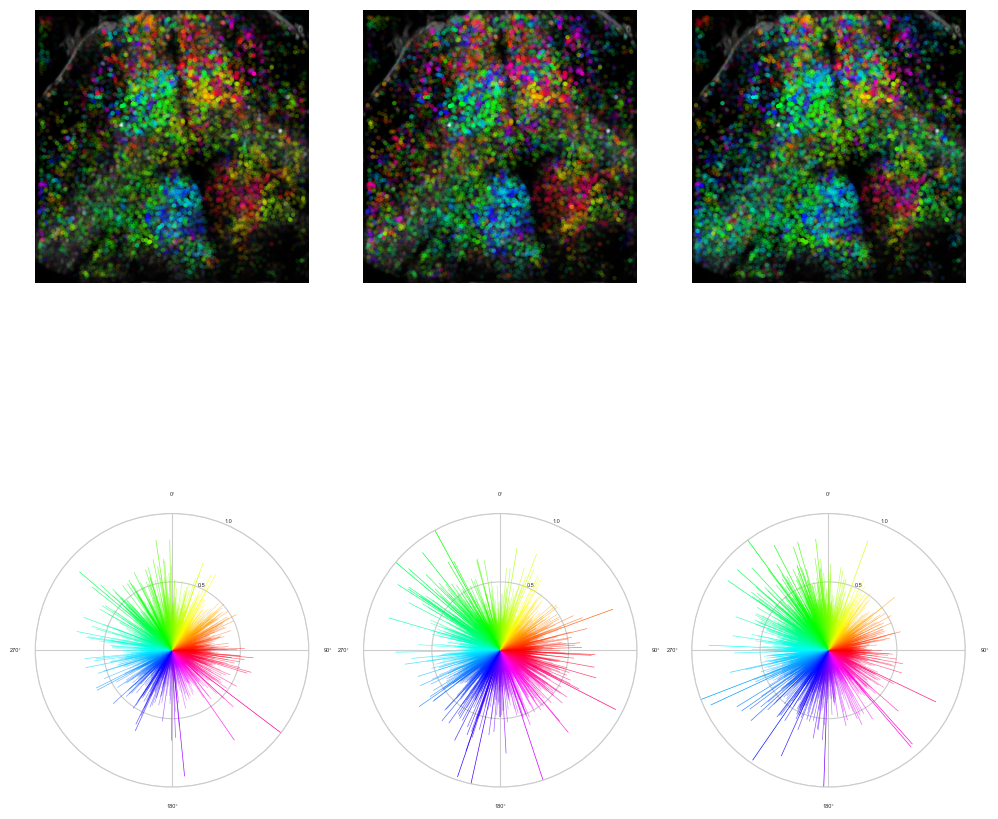

In [9]:
tuned = get_tuned(fish, f_pertrial_dict, baseline_s =5, response_s = 15, stim_onset_type = 'gratings')
plot_rainbow_omrtuning(fish, tuned)

__barcoding__

In [10]:
def select_dotbarcode(fish, f_pertrial_dict, baseline_s =10, response_s = 10, perc_trial_threshold = 0.8):
    """Select barcoded neurons with 1.8std above baseline and below 1.8std for the opposite stimulus"""
    #TODO: replace xpos with rois
    #build a neuron accumulator
    stim_list = fish.stimulus_df.stim_name.unique()
    dot_stim = [s for s in stim_list if ('dot' in s) and ('[' not in s)]
    image_s = np.diff(fish.frametimes_dict[0]).mean()
    all_n_index = []
    for plane in fish.planes:
        all_n_index = all_n_index + list(fish.f_dict[plane].index)
    barcode = pd.DataFrame(columns = dot_stim, index = all_n_index)
    for stim in dot_stim:
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        stationary_time = stim_df['stationary_time'].iloc[0]
        #define plotting range (what are the frames of data to grab in general)
        stationary_frame = int(stationary_time/image_s)
        baseline_frame = int((stationary_time - baseline_s)/ image_s)#how many frame before stationary frame
        response_frame = int((stationary_time + response_s)/ image_s)#how many frame after stationary frame
        #get all the baseline per trial
        f_pertrial = f_pertrial_dict[stim]
        f_pertrial_baseline = f_pertrial[:, :, baseline_frame:stationary_frame]
        f_pertrial_response = f_pertrial[:, :, stationary_frame:response_frame]
        f_pertrial_baselinemean = np.mean(f_pertrial_baseline, axis = 2)
        f_pertrial_baselinestd = np.std(f_pertrial_baseline, axis = 2)
        f_pertrial_responsemean = np.mean(f_pertrial_response, axis = 2)
        #if response > baselien + 1.8*std
        f_responding = (f_pertrial_responsemean - f_pertrial_baselinemean)/f_pertrial_baselinestd >= 1.8
        f_responding_percentage = np.divide(np.sum(f_responding, axis = 0), f_responding.shape[0])
        barcode.loc[:, stim] = f_responding_percentage
    #actually picking barcode neurons
    barred_neurons = {s: None for s in dot_stim}
    for stim in dot_stim:
        #opp_stim = utils.angles_omr[(utils.omr_angles[stim]+ 180)%360]
        barred_neurons[stim] = list(barcode[(barcode[stim] >= perc_trial_threshold)].index)
    return barred_neurons

def select_omrbarcode(fish, f_pertrial_dict, baseline_s =10, response_s = 10, perc_trial_threshold = 0.8):
    """Select barcoded neurons with 1.8std above baseline and below 1.8std for the opposite stimulus"""
    #TODO: replace xpos with rois
    #build a neuron accumulator
    stim_list = fish.stimulus_df.stim_name.unique()
    omr_stim = [s for s in stim_list if 'dot' not in s]
    image_s = np.diff(fish.frametimes_dict[0]).mean()
    all_n_index = []
    for plane in fish.planes:
        all_n_index = all_n_index + list(fish.f_dict[plane].index)
    barcode = pd.DataFrame(columns = omr_stim, index = all_n_index)
    for stim in omr_stim:
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        stationary_time = stim_df['stationary_time'].iloc[0]
        #define plotting range (what are the frames of data to grab in general)
        stationary_frame = int(stationary_time/image_s)
        baseline_frame = int((stationary_time - baseline_s)/ image_s)#how many frame before stationary frame
        response_frame = int((stationary_time + response_s)/ image_s)#how many frame after stationary frame
        #get all the baseline per trial
        f_pertrial = f_pertrial_dict[stim]
        f_pertrial_baseline = f_pertrial[:, :, baseline_frame:stationary_frame]
        f_pertrial_response = f_pertrial[:, :, stationary_frame:response_frame]
        f_pertrial_baselinemean = np.mean(f_pertrial_baseline, axis = 2)
        f_pertrial_baselinestd = np.std(f_pertrial_baseline, axis = 2)
        f_pertrial_responsemean = np.mean(f_pertrial_response, axis = 2)
        #if response > baselien + 1.8*std
        f_responding = (f_pertrial_responsemean - f_pertrial_baselinemean)/f_pertrial_baselinestd >=  1.8
        f_responding_percentage = np.divide(np.sum(f_responding, axis = 0), f_responding.shape[0])
        barcode.loc[:, stim] = f_responding_percentage
    #actually picking barcode neurons
    barred_neurons = {s: None for s in omr_stim}
    for stim in omr_stim:
        nostim = [s for s in omr_stim if s!= stim]
        #opp_stim = utils.angles_omr[(utils.omr_angles[stim]+ 180)%360]
        barred_neurons[stim] = list(barcode[(barcode[stim] >= perc_trial_threshold) & (barcode[nostim].max(axis = 1) < perc_trial_threshold)].index)
    return barred_neurons


def select_omrtuned(fish, tuned, angle_diff=15):
    """
    Select top tuned neurons according to tuned angles ,where the tuned angles is within angle_range, and the tuned weights is 1.8std above the STD + mean of the population tuned weights
    :param fish: 
    :param tuned: 
    :return: 
    """
    stim_list = fish.stimulus_df.stim_name.unique()
    omr_stim = [s for s in stim_list if 'dot' not in s]
    barred_neurons = {s: None for s in omr_stim}
    #make sure tuned only include the omr_stim
    tuned = tuned.copy()[omr_stim + ['_weighted_angle', '_weights']]
    for stim in omr_stim:
        #criteria 1: only tuned towards the correct stimuli
        anglestim = utils.omr_angles[stim]
        angle_range = (anglestim - angle_diff, anglestim + angle_diff)
        neurons_angleresponders = tuned[
            utils.is_within_short_arc(tuned['_weighted_angle'], angle_range[0], angle_range[1])].index
        #TODO: criteria 2: within roi
        #criteria 4: 1.8 STD above the population mean of tuned weights 
        neurons_topresponders = tuned[
            tuned['_weights'] >= np.mean(tuned['_weights']) + 1.8 * np.std(tuned['_weights'], axis=0)].index
        barred_neurons[stim] = list(set(neurons_angleresponders) & set(neurons_topresponders))
    return barred_neurons

In [11]:
#barred_neurons = select_omrbarcode(fish, f_pertrial_dict, baseline_s =20, response_s = 5, perc_trial_threshold = 0.8)
barred_neurons = select_omrtuned(fish, tuned, 30)
barred_dotneurons = select_dotbarcode(fish, f_pertrial_dict, baseline_s =5, response_s = 10, perc_trial_threshold = 0.6)


In [13]:
#smooth eye behavior
#preprocess eyes
fish.eye_df.loc[:, 'th_e0_smooth'] = utils.butter_lowpass_filter((fish.eye_df['th_e0']), cutoff = .8, fs = 90, order=1)
#fish.eye_df.loc[:, 'th_e0_smooth'] = np.subtract(fish.eye_df['th_e0_smooth'], np.mean(fish.eye_df['th_e0_smooth']))
fish.eye_df.loc[:, 'th_e1_smooth']  = utils.butter_lowpass_filter((fish.eye_df['th_e1']), cutoff = .8, fs = 90, order=1)
#fish.eye_df.loc[:, 'th_e1_smooth'] = np.subtract(fish.eye_df['th_e1_smooth'], np.mean(fish.eye_df['th_e1_smooth']))

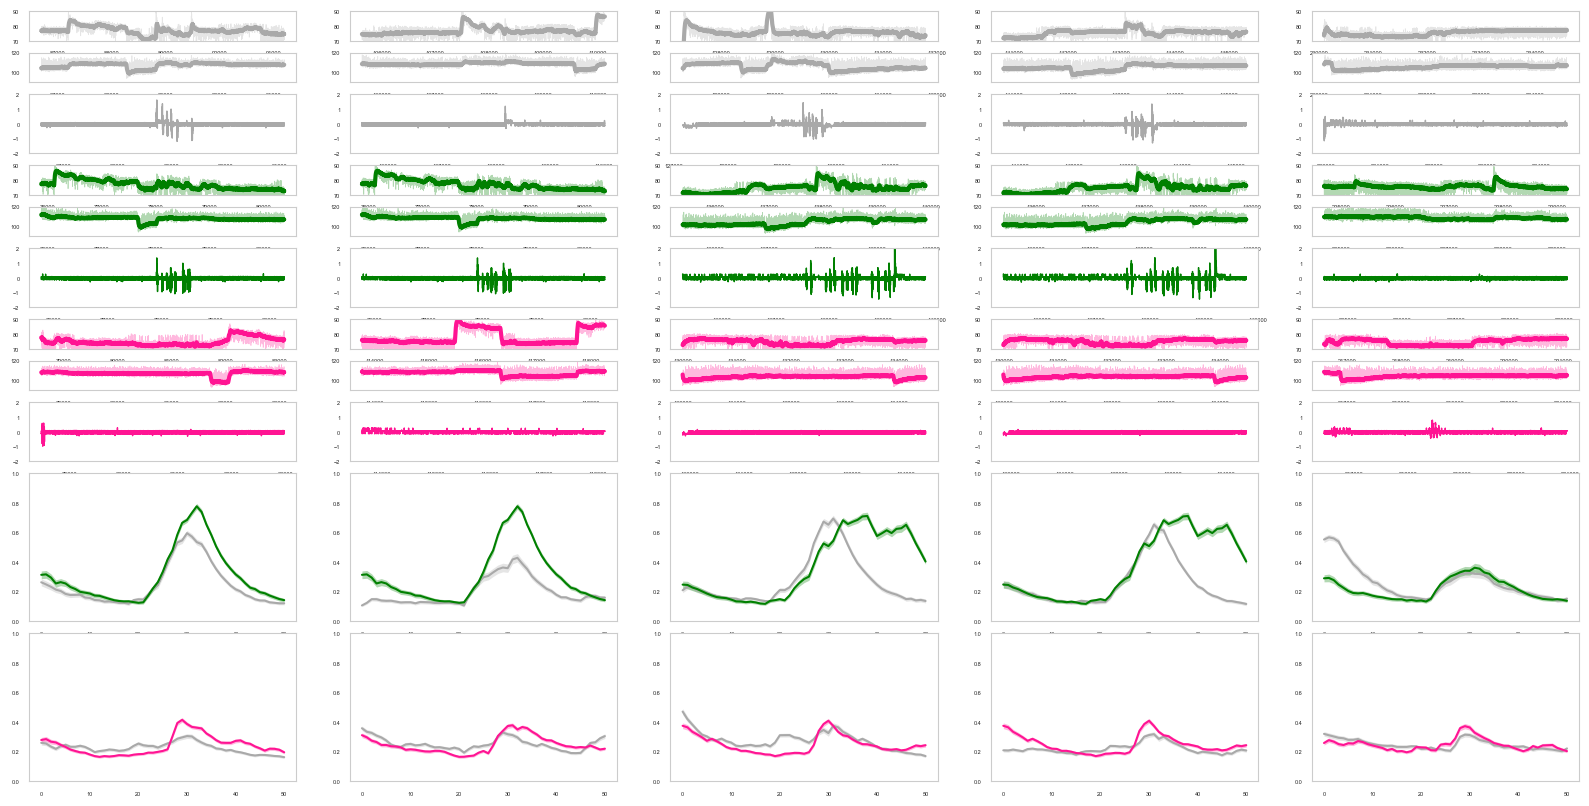

In [46]:
def plot_eye_tail_omr_dot(fish, t_start, ax_e0, ax_e1, ax_tail, ax_omr, ax_dot, omr_barred_neuron, dot_barred_neuron, omr_stim, dot_stim, color, n):
    #plot behavior traces
    eye_segment = fish.eye_df[fish.eye_df.real_time_s.between(t_start, t_start + 30 + 20)]
    ax_e0.plot(eye_segment.th_e0, linewidth = .5, color = color, alpha = 0.3)
    ax_e1.plot(eye_segment.th_e1, linewidth = .5, color = color, alpha = 0.3)
    ax_e0.plot(eye_segment.th_e0_smooth, linewidth = 3, color = color)
    ax_e1.plot(eye_segment.th_e1_smooth, linewidth = 3, color = color)
    tail_segment = fish.tail_df[fish.tail_df.real_time_s.between(t_start, t_start + 30 + 20)]
    ax_tail.plot(tail_segment.tail_sum, linewidth = 1, color = color)
    ax_tail.set_ylim([-2, 2])
    ax_e0.set_ylim([70, 90])
    ax_e1.set_ylim([90, 120])
    #plot neurons responses -OMR
    if omr_stim != 'skip':
        f_trial = f_pertrial_dict[omr_stim][n, omr_barred_neuron]
        mean_trace = f_trial.mean(axis = 0)
        sem_trace = np.std(f_trial, axis=0, ddof=1) / np.sqrt(len(omr_barred_neuron))
        ci_95 = 1.96 * sem_trace
        ax_omr.plot(mean_trace, color = color)
        ax_omr.fill_between(range(len(mean_trace)), mean_trace - ci_95, mean_trace + ci_95, color= color, alpha=0.3, linewidth = 0)
        ax_omr.set_ylim([0,1])
    #plot neurons responses -DOT
    if dot_stim != 'skip':
        omr_stimdf
        f_trial = f_pertrial_dict[dot_stim][n, dot_barred_neuron]
        mean_trace = f_trial.mean(axis = 0)
        sem_trace = np.std(f_trial, axis=0, ddof=1) / np.sqrt(len(dot_barred_neuron))
        ci_95 = 1.96 * sem_trace
        ax_dot.plot(mean_trace, color = color)
        ax_dot.fill_between(range(len(mean_trace)), mean_trace - ci_95, mean_trace + ci_95, color= color, alpha=0.3, linewidth = 0)
        ax_dot.set_ylim([0,1])

stim = "['dot_l', 'forward']"
omr_stim = stim.split("'")[3]
dot_stim = stim.split("'")[1]
stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim]
omr_stimdf = fish.stimulus_df[fish.stimulus_df['stim_name'] == omr_stim]
dot_stimdf = fish.stimulus_df[fish.stimulus_df['stim_name'] == dot_stim]
#get corresponding neurons
omr_barred_neuron = barred_neurons[omr_stim]
dot_barred_neuron = barred_dotneurons[dot_stim]
fig, ax = plt.subplots(11, len(stim_df), figsize = (20, 10), gridspec_kw = {'height_ratios': [1, 1, 2, 1, 1, 2, 1, 1,2 ,5,5]})
n = 0
for _, stimrow in stim_df.iterrows():
    t_start = stimrow['real_starttime_s']
    ax_e0 = ax[0, n]
    ax_e1 = ax[1, n]
    ax_tail = ax[2, n]
    ax_omr = ax[9, n]
    ax_dot = ax[10, n]
    plot_eye_tail_omr_dot(fish, t_start, ax_e0, ax_e1, ax_tail, ax_omr, ax_dot, omr_barred_neuron, dot_barred_neuron, stim, stim, color = 'darkgrey', n = n)

    #find the closest mean grating stim
    ax_e0 = ax[3, n]
    ax_e1 = ax[4, n]
    ax_tail = ax[5, n]
    omr_t_start = omr_stimdf.loc[(omr_stimdf["real_starttime_s"] - t_start).abs().idxmin(), "real_starttime_s"]
    omr_n = omr_stimdf.index.get_loc((omr_stimdf["real_starttime_s"] - t_start).abs().idxmin())
    plot_eye_tail_omr_dot(fish, omr_t_start, ax_e0, ax_e1, ax_tail, ax_omr, 'skip', omr_barred_neuron, dot_barred_neuron, omr_stim, dot_stim = 'skip', color = 'green', n = omr_n)
    #fidn the closest mean dot stim
    ax_e0 = ax[6, n]
    ax_e1 = ax[7, n]
    ax_tail = ax[8, n]
    dot_t_start = dot_stimdf.loc[(dot_stimdf["real_starttime_s"] - t_start).abs().idxmin(), "real_starttime_s"]
    dot_n = dot_stimdf.index.get_loc((dot_stimdf["real_starttime_s"] - t_start).abs().idxmin())
    plot_eye_tail_omr_dot(fish, dot_t_start, ax_e0, ax_e1, ax_tail, 'skip', ax_dot, omr_barred_neuron, dot_barred_neuron, 'skip', dot_stim, color = 'deeppink', n = dot_n)

    for axes in ax[:, n]:
        axes.grid(False)
    n += 1

In [121]:
stim_matrix =  np.array(['dot_l', 'dot_r',
                        'forward', "['dot_l', 'forward']", "['dot_r', 'forward']",
                        'left', "['dot_l', 'left']", "['dot_r', 'left']",
                        'right', "['dot_l', 'right']", "['dot_r', 'right']",
                        'backward', "['dot_l', 'backward']", "['dot_r', 'backward']"])
stim_matrix = ['dot_l', 'dot_r']
f_pertrial_dictselect = {stim: f_pertrial_dict[stim] for stim in stim_matrix}

In [122]:
f_acc = np.array([f_pertrial_dictselect[stim].mean(axis = 0) for stim in f_pertrial_dictselect.keys()])
f_acc = f_acc.reshape((f_acc.shape[1], f_acc.shape[0] * f_acc.shape[2]))
f_acc.shape

(14710, 102)

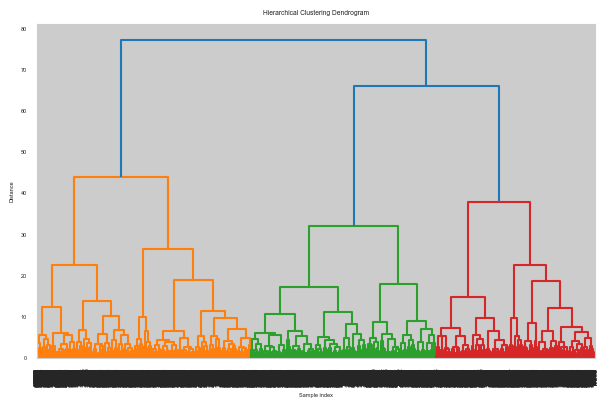

In [123]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# --- Step 2: Perform hierarchical clustering ---
Z = linkage(f_acc, method='ward')  # 'ward', 'average', 'complete', 'single', etc.

# --- Step 3: Plot dendrogram ---
plt.figure(figsize=(6, 4))
dendrogram(Z, labels=np.arange(len(f_acc)))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [126]:
# --- Step 4: Cut the dendrogram to get clusters ---
max_distance = 30  # adjust as needed
clusters = fcluster(Z, t=max_distance, criterion='distance')

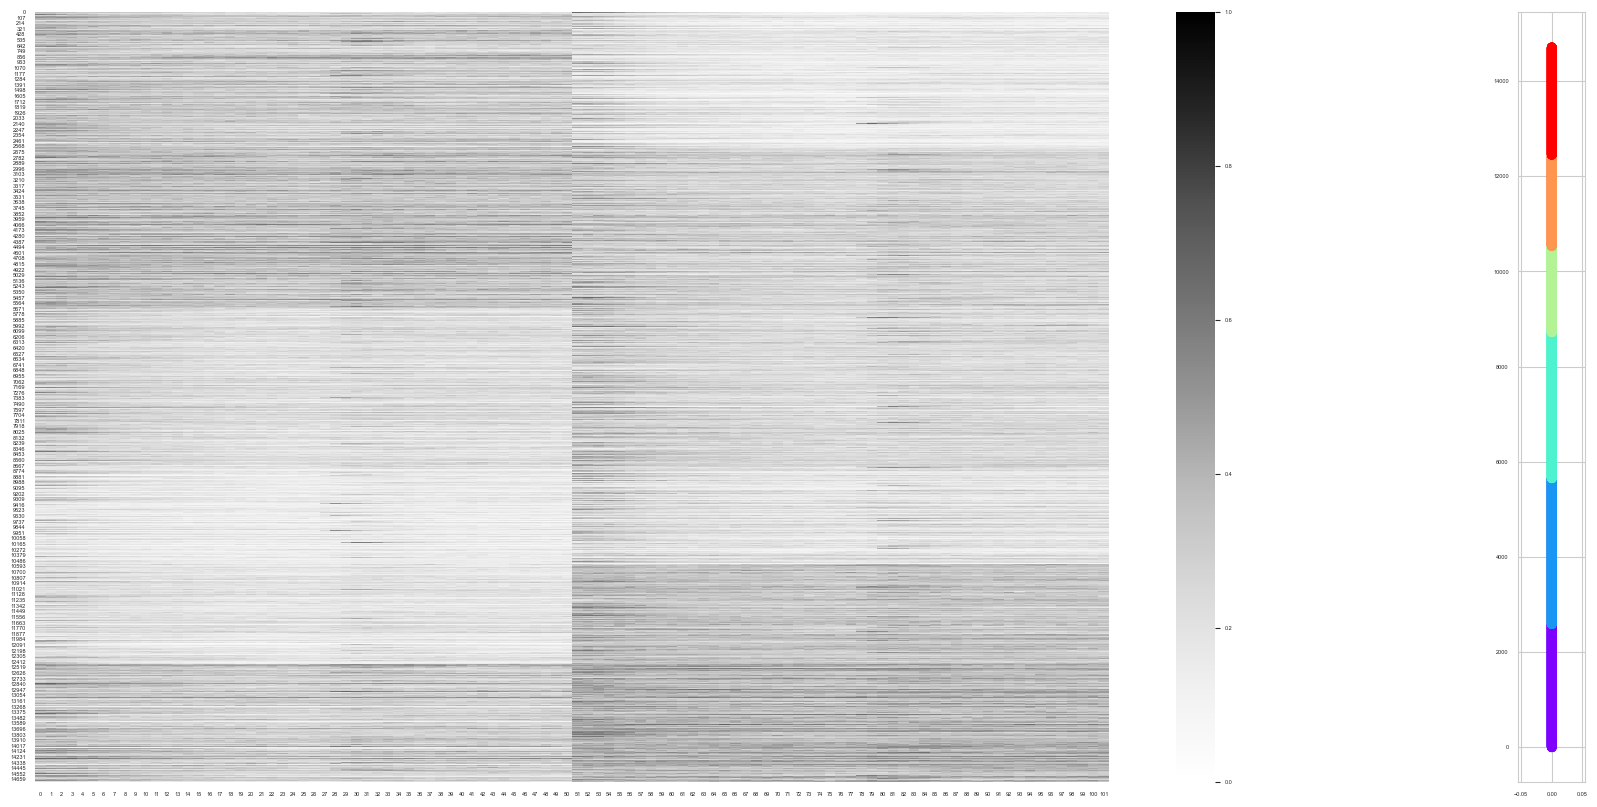

In [127]:
sorted_idx = np.argsort(clusters)
clusters_sort = np.sort(clusters)
fig, ax = plt.subplots(1, 2, figsize = (20, 10), gridspec_kw = {'width_ratios': [20, 1]})
sns.heatmap(f_acc[sorted_idx], vmin = 0, vmax = 1, cmap = 'Greys', ax = ax[0])
ax[1].scatter([0] * len(clusters), range(0, len(clusters)), c = clusters_sort, cmap = 'rainbow')

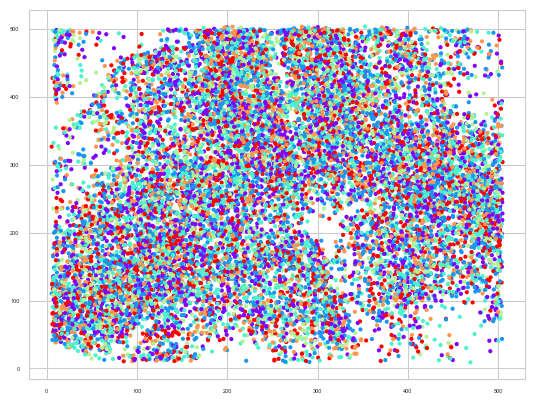

In [128]:
fish.pos_all = pd.concat([fish.pos_dict[i] for i in fish.planes])
plt.scatter(fish.pos_all['xpos'], fish.pos_all['ypos'], c = clusters, cmap = 'rainbow', s = 4)

In [106]:
fish.pos_all

array([[269.95364238,  13.31788079,   0.        ],
       [385.75478927, 145.35632184,   0.        ],
       [239.11341853, 134.86102236,   0.        ],
       ...,
       [310.13207547, 374.69811321,   4.        ],
       [ 59.26627219, 200.6035503 ,   4.        ],
       [ 69.8852459 ,  54.54098361,   4.        ]], shape=(14710, 3))